# Optimal Fed-Batch Control of Induced Foreign Protein Production by Recombinant Bacteria

This notebook is based on the fed-batch bioreactor model described in the seminal paper:

**Lee, J., & Ramirez, W. F. (1994).** [Optimal fed-batch control of induced foreign protein production by recombinant bacteria](https://doi.org/10.1002/aic.690400516). *AIChE Journal*, 40(5), 913–928.

The paper develops an optimal control strategy for maximizing the production of foreign proteins in a fed-batch process using recombinant *E. coli*, modeled as a system of ordinary differential equations (ODEs).

---

## System of ODEs

The model describes the dynamic evolution of five key state variables in a fed-batch reactor:

### 1. Biomass balance

$
\frac{dX}{dt} = \mu(S) \cdot X - D(t) \cdot X
$

### 2. Substrate (glucose) balance
$
\frac{dS}{dt} = -\frac{1}{Y_{X/S}} \mu(S) \cdot X + D(t) \cdot (S_{\text{in}} - S)
$

### 3. Inducer (e.g., IPTG) balance
$
\frac{dI}{dt} = D(t) \cdot (I_{\text{in}} - I) - k_d \cdot I
$

### 4. Protein balance
$
\frac{dP}{dt} = r_P(X, I) - D(t) \cdot P
$

### 5. Volume balance
$
\frac{dV}{dt} = F(t)
$

---

## Algebraic Expressions

### Specific growth rate (Monod kinetics)
$
\mu(S) = \mu_{\text{max}} \cdot \frac{S}{K_S + S}
$

### Protein synthesis rate
$
r_P(X, I) = k_P \cdot X \cdot \frac{I}{K_I + I}
$

### Dilution rate
$
D(t) = \frac{F(t)}{V(t)}
$

---

## Model Variables

| Symbol       | Description                                 | Units           |
|--------------|---------------------------------------------|-----------------|
| $ X $      | Biomass concentration                       | g/L             |
| $ S $      | Substrate (glucose) concentration           | g/L             |
| $ I $      | Inducer concentration                       | mM or g/L       |
| $ P $      | Foreign protein concentration               | g/L             |
| $ V $      | Culture volume                              | L               |
| $ F(t) $   | Feed flow rate (control variable)           | L/h             |
| $ D(t) $   | Dilution rate = \( F/V \)                   | 1/h             |

---

## Parameters

| Parameter         | Description                                  | Units        |
|------------------|----------------------------------------------|--------------|
| $ \mu_{\text{max}} $ | Maximum specific growth rate            | 1/h          |
| $ K_S $         | Monod constant for substrate                 | g/L          |
| $ Y_{X/S} $     | Biomass yield on substrate                   | g/g          |
| $ k_P $         | Protein production coefficient               | 1/h          |
| $ K_I $         | Saturation constant for inducer              | mM or g/L    |
| $ k_d $         | Inducer degradation rate constant            | 1/h          |
| $ S_{\text{in}} $ | Substrate concentration in feed            | g/L          |
| $ I_{\text{in}} $ | Inducer concentration in feed              | mM or g/L    |

---

> The control objective in the original study was to optimize the feed flow rate \( F(t) \) over time to maximize protein concentration at the end of the batch, subject to constraints on reactor volume and nutrient consumption.
---

## Initial Conditions

The initial concentrations used in simulations or experiments may vary. Below is a typical example set (can be extended per experimental setup).

| Variable        | Description                     | Initial Value | Units | Notes                    |
|----------------|---------------------------------|---------------|--------|--------------------------|
| $ X_0 $       | Initial biomass                 | 0.1           | g/L    | Inoculum concentration   |
| $ S_0 $       | Initial glucose concentration   | 5.0           | g/L    | Can vary by batch        |
| $ I_0 $       | Initial inducer concentration   | 0.0           | mM     | Induction starts later   |
| $ P_0 $       | Initial product concentration   | 0.0           | g/L    | Always zero initially    |
| $ V_0 $       | Initial culture volume          | 1.0           | L      | Usually starting volume  |

---

## Model Parameters

Parameter values can vary between experiments or literature sources. The table below includes typical values, with ranges or standard deviations when reported.

| Parameter           | Description                                | Value      | Units  | Range / SD         | Notes                        |
|---------------------|--------------------------------------------|------------|--------|--------------------|------------------------------|
| $ \mu_{\text{max}} $ | Max specific growth rate                | 0.6        | 1/h    | 0.4–0.8            | Depends on strain & media    |
| $ K_S $           | Monod constant for substrate               | 0.1        | g/L    | —                  | Typical for glucose          |
| $ Y_{X/S} $       | Biomass yield on substrate                 | 0.5        | g/g    | —                  | Biomass per g of glucose     |
| $ k_P $           | Protein production coefficient             | 0.05       | 1/h    | ±0.01              | Empirical fit                |
| $ K_I $           | Inducer saturation constant                | 0.1        | mM     | —                  | e.g., IPTG half-saturation   |
| $ k_d $           | Inducer degradation rate                   | 0.01       | 1/h    | —                  | Low for stable inducers      |
| $ S_{\text{in}} $ | Glucose concentration in feed              | 500        | g/L    | —                  | Highly concentrated solution |
| $ I_{\text{in}} $ | Inducer concentration in feed              | 10.0       | mM     | —                  | Inducer spike concentration  |

> If experiments differ significantly (e.g., wild-type vs engineered strain), tables can be split or extended by experimental condition.



In [1]:
# ODE + Algebraic model template for fed-batch bioreactor (Monod + protein induction)

from typing import Dict, Tuple
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import os

In [2]:

# === Algebraic functions ===
def algebraic_functions(mode: str, state: np.ndarray, params: Dict[str, float]) -> Dict[str, float]:
    """
    Computes algebraic expressions from current state and parameters.
    
    Parameters:
        state: np.ndarray, [X, S, I, P, V]
        params: dict, model parameters (must include mode and possibly F)
        
    Returns:
        dict with computed algebraic terms like mu, r_P, D, F
    """

    X, S, I, P, V = state

    # Enforce non-negative substrate
    #S = max(S, 0.0)

    # Determine feed rate F(t)
    if mode == "batch":
        F = 0.0
    elif mode == "fed-batch":
        F = params.get("F", 0.0)
    elif mode == "continuous":
        F = params.get("F", 0.0)  # Must be balanced with outflow
    else:
        raise ValueError(f"Unknown mode: {mode}. Use 'batch', 'fed-batch', or 'continuous'.")

    mu = params["mu_max"] * S / (params["K_S"] + S + 1e-8)
    r_P = params["k_P"] * X * I / (params["K_I"] + I + 1e-8)
    D = F / (V + 1e-8) # reamain positive in FB and C modes, is null in B mode 

    return {
        "mu": mu,
        "r_P": r_P,
        "D": D,
        "F": F
    }


# === ODE system ===
def fed_batch_odes(mode: str, t: float, state: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    """
    Defines the ODE system for batch, fed-batch, or continuous reactor.
    
    Parameters:
        t: float, current time
        state: np.ndarray, [X, S, I, P, V]
        params: dict, model parameters (must include mode and feed settings)
    
    Returns:
        dstate_dt: np.ndarray, derivatives [dX/dt, dS/dt, dI/dt, dP/dt, dV/dt]
    """
    # correcting S(t) and dS(t) to avoid negative S (1)
    state[1] = max(state[1], 0.0)
    X, S, I, P, V = state

    alg = algebraic_functions(mode, state, params) 

    

    dXdt = alg["mu"] * X - alg["D"] * X
    dSdt = - (1 / params["Y_XS"]) * alg["mu"] * X + alg["D"] * (params["S_in"] - S)
    dIdt = alg["D"] * (params["I_in"] - I) - params["k_d"] * I
    dPdt = alg["r_P"] - alg["D"] * P
    dVdt = alg["F"] if mode != "continuous" else 0.0  # Constant volume in continuous mode


    return np.array([dXdt, dSdt, dIdt, dPdt, dVdt])


# === Load Parameters and Initial Conditions from CSV ===
def load_model_inputs(param_file: str, init_file: str) -> Tuple[Dict[str, float], np.ndarray]:
    df_params = pd.read_csv(param_file)
    df_init = pd.read_csv(init_file)

    
    params = dict(zip(df_params["Parameter"], df_params["Value"]))
    
    init_values = np.array(df_init["InitialValue"])
    # special case for mode == "batch" (we need non-null inducer at t = 0 if we want to see changes)
    init_values[list(initial_conditions.keys()).index("I0")] = params["I_in"] if mode == "batch" else init_values[list(initial_conditions.keys()).index("I0")] 

    return params, init_values
# === Run Simulation ===
def simulate_fed_batch(mode: str,params: Dict[str, float], initial_conditions: np.ndarray,
                       t_span: Tuple[float, float], t_eval = None):
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 200)

    sol = solve_ivp(
        fun=lambda t, y: fed_batch_odes(mode,t, y, params),
        t_span=t_span,
        y0=initial_conditions,
        t_eval=t_eval,
        method="LSODA"
    )
    return sol

# === Plot and Save Results ===
def plot_fed_batch_results_separately(mode,result, save_figs = False):
    """Plot each state variable in a separate figure and save them."""
    t = result.t
    labels = ['Biomass', 'Substrate', 'Inducer', 'Protein', 'Volume'] 
    abbrvs = ["X","S","I","P","V"]
    units  = ["g/L","g/L","mM","g/L","L"] 
    variables = result.y

    for i, (unit,label,abbrv,data) in enumerate(zip(units,labels,abbrvs,variables)):
        plt.figure(figsize=(6, 4))
        plt.plot(t, data, label=abbrv, linewidth=2)
        plt.xlabel("Time ($h$)")
        plt.ylabel(f"${unit}$")
        plt.title(label)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        
        if save_figs:
            filename = f"{output_folder}{mode}_{label.split()[0].lower()}.png"
            plt.savefig(filename)

        plt.show()

# functions to generate simulations dataset for training
def sample_params_from_bounds(param_bounds: Dict[str, Tuple[float, float, float]]) -> Dict[str, float]:
    return {key: np.random.uniform(*[param_bounds[key][0], param_bounds[key][2]]) for key in param_bounds}

def generate_nonregular_timesteps(t_min: float, t_max: float, n: int = 10) -> np.ndarray:
    return np.sort(np.random.uniform(t_min, t_max, n))

def simulate_single_run(mode: str, param_bounds: Dict[str, Tuple[float, float, float]],
                        init_conditions: Dict[str, float], t_ticks: np.ndarray) -> Tuple[Dict[str, float], np.ndarray]:
    params = sample_params_from_bounds(param_bounds)
    y0 = np.array([init_conditions["X0"], init_conditions["S0"],
                   init_conditions["I0"], init_conditions["P0"], init_conditions["V0"]])
    sol = solve_ivp(fun=lambda t, y: fed_batch_odes(mode, t, y, params),
                    t_span=(t_ticks.min(), t_ticks.max()), y0=y0, t_eval=t_ticks, method="LSODA")
    Y = sol.y[[0, 3], :].T  # Biomass and Protein
    return params, Y

def generate_training_dataset(mode: str, param_bounds: Dict[str, Tuple[float, float, float]],
                              init_conditions: Dict[str, float], n_samples: int = 100,
                              t_span: Tuple[float, float] = (0.0, 24.0), output_path: str = "sim_training_data") -> None:
    os.makedirs(output_path, exist_ok=True)
    all_X, all_Y = [], []

    for _ in range(n_samples):
        t_ticks = generate_nonregular_timesteps(t_span[0], t_span[1], n=10)
        X_dict, Y_array = simulate_single_run(mode, param_bounds, init_conditions, t_ticks)

        # Flatten output: t0, ..., t9, X_t0, P_t0, ..., X_t9, P_t9
        t_row = t_ticks.tolist()
        y_row = Y_array.flatten().tolist()
        combined_row = t_row + y_row
        all_X.append([X_dict[k] for k in sorted(X_dict.keys())])
        all_Y.append(combined_row)

    X_df = pd.DataFrame(all_X, columns=sorted(param_bounds.keys()))
    time_columns = [f"t{i}" for i in range(10)]
    value_columns = [f"{var}_t{i}" for i in range(10) for var in ["X", "P"]]
    Y_df = pd.DataFrame(all_Y, columns=time_columns + value_columns)
    
    X_df.to_csv(os.path.join(output_path, f"{mode}_sim_X_parameters.csv"), index=False)
    Y_df.to_csv(os.path.join(output_path, f"{mode}_sim_Y_outputs.csv"), index=False)


In [3]:
# Data processing
# Update parameters dictionary to include (min, value, max) for each parameter
allvars = ["X", "S", "I", "P", "V"]
allprm  = ["mu_max", "K_S", "Y_XS", "k_P", "K_I", "k_d", "S_in", "I_in", "F"]    

params_bounds = {
    "mu_max": (0.4, 0.6, 0.8),     # 1/h
    "K_S"   : (0.05, 0.1, 0.2),       # g/L
    "Y_XS"  : (0.4, 0.5, 0.6),       # g/g
    "k_P"   : (0.03, 0.05, 0.07),     # 1/h
    "K_I"   : (0.05, 0.1, 0.2),       # mM
    "k_d"   : (0.005, 0.01, 0.02),    # 1/h
    "S_in"  : (400.0, 500.0, 600.0), # g/L
    "I_in"  : (5.0, 10.0, 15.0),     # mM
    "F"     : (0.05, 0.1, 0.2)          # L/h
}

# Convert to DataFrame
df_params_bounds = pd.DataFrame([
    {"Parameter": key, "Min": v[0], "Value": v[1], "Max": v[2]}
    for key, v in params_bounds.items()
])

input_folder  = "./playground_folders/inputs/"
output_folder = "./playground_folders/outputs/"
# Save to CSV
df_params_bounds.to_csv(f"{input_folder}model_parameters_with_bounds.csv", index=False)


# Define initial conditions dictionary
initial_conditions = {
    "X0": 0.1,  # g/L
    "S0": 5.0,  # g/L
    "I0": 0.0 ,  # mM
    "P0": 0.0,  # g/L
    "V0": 1.0   # L
}

# Save to CSV files
df_init = pd.DataFrame(list(initial_conditions.items()), columns=["Variable", "InitialValue"])

# File output
df_init.to_csv(f"{input_folder}initial_conditions.csv", index=False)


In [4]:
## Preruning the model
mode  = "continuous"
tspan = (0.0,24.0) 
params, init_conds = load_model_inputs(f"{input_folder}model_parameters_with_bounds.csv",f"{input_folder}initial_conditions.csv")

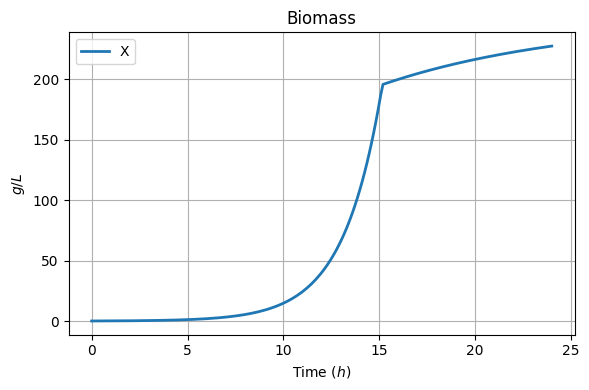

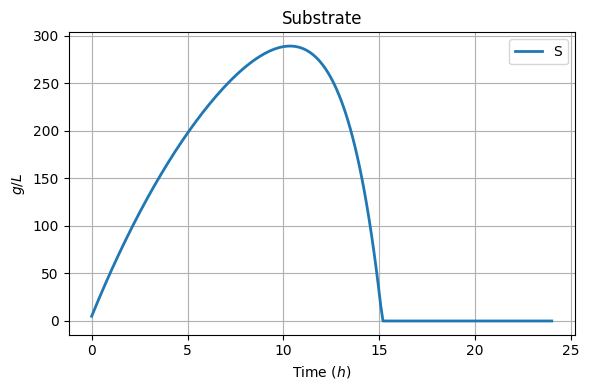

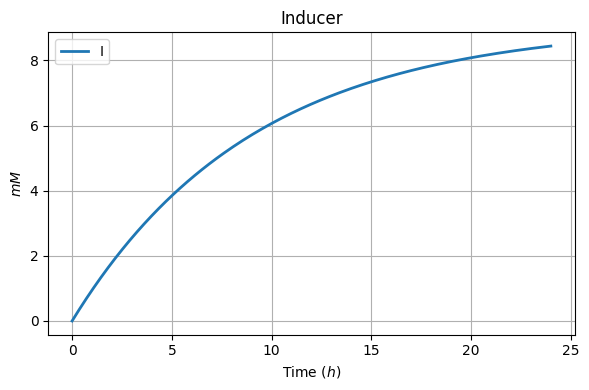

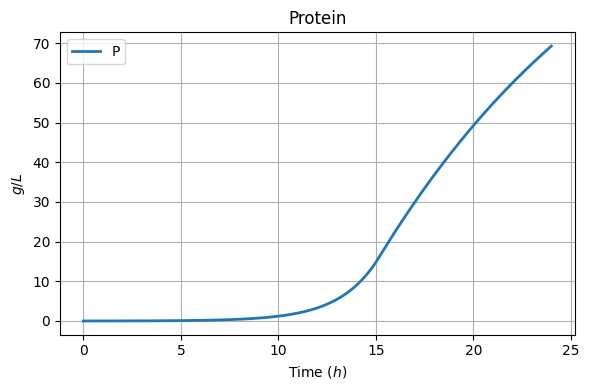

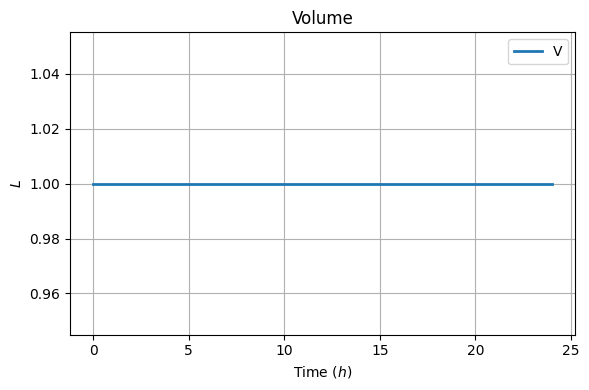

In [5]:
# Runing the model
my_sol = simulate_fed_batch(mode,params, init_conds, tspan)
plot_fed_batch_results_separately(mode,my_sol,save_figs=True)

In [6]:
generate_training_dataset(mode, params_bounds, initial_conditions, 100, tspan, output_path =  "./playground_folders/inputs/")

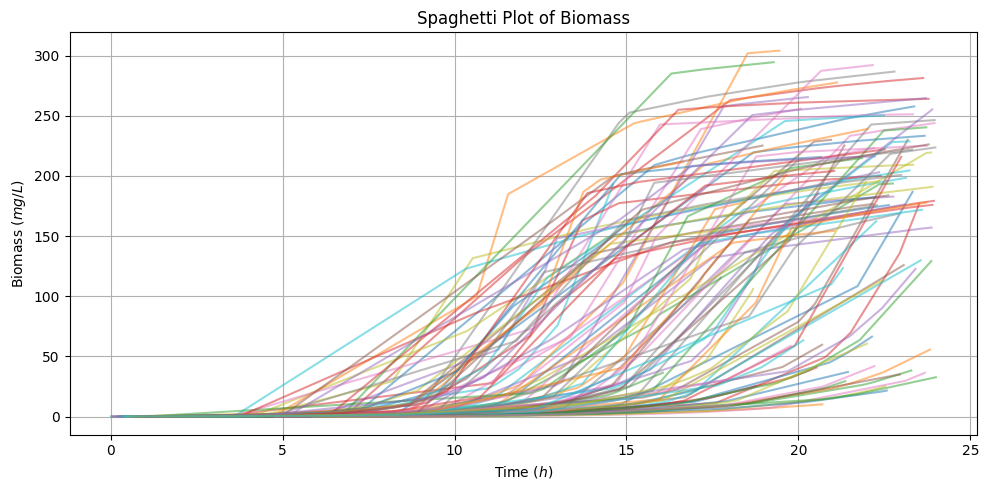

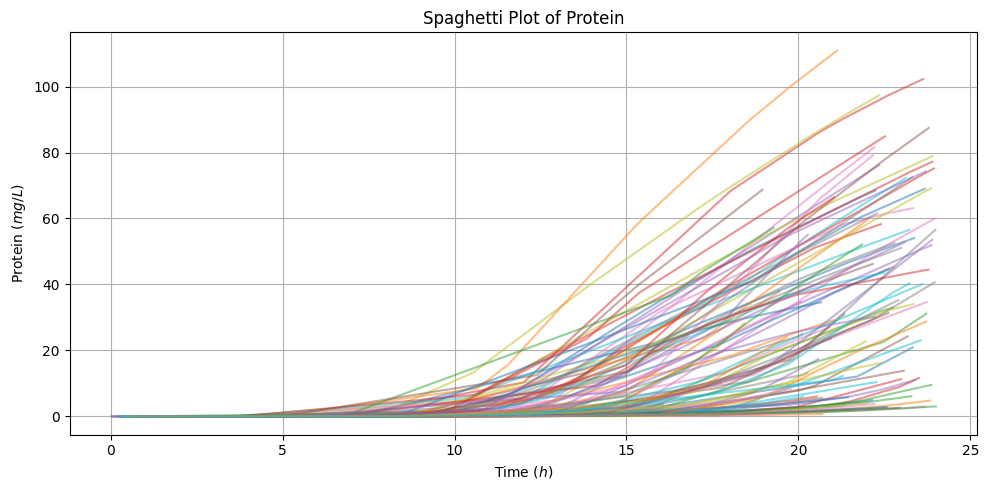

In [7]:
# Load CSV
file_path = './playground_folders/inputs/continuous_sim_Y_outputs.csv'
df = pd.read_csv(file_path)

# Number of time steps per sample
n_timepoints = 10
# Extract time ticks
time_ticks = df.iloc[:, 0:n_timepoints]

# Extract biomass and protein from alternating columns
biomass = df.iloc[:, n_timepoints + 0::2].iloc[:, :n_timepoints]   # even columns after time
protein = df.iloc[:, n_timepoints + 1::2].iloc[:, :n_timepoints]   # odd columns after time

# Plot Biomass Spaghetti Plot
plt.figure(figsize=(10, 5))
for i in range(len(df)):
    plt.plot(time_ticks.iloc[i], biomass.iloc[i], alpha=0.5)
plt.title("Spaghetti Plot of Biomass")
plt.xlabel("Time ($h$)")
plt.ylabel("Biomass ($mg/L$)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Protein Spaghetti Plot
plt.figure(figsize=(10, 5))
for i in range(len(df)):
    plt.plot(time_ticks.iloc[i], protein.iloc[i], alpha=0.5)
plt.title("Spaghetti Plot of Protein")
plt.xlabel("Time ($h$)")
plt.ylabel("Protein ($mg/L$)")
plt.grid(True)
plt.tight_layout()
plt.show()

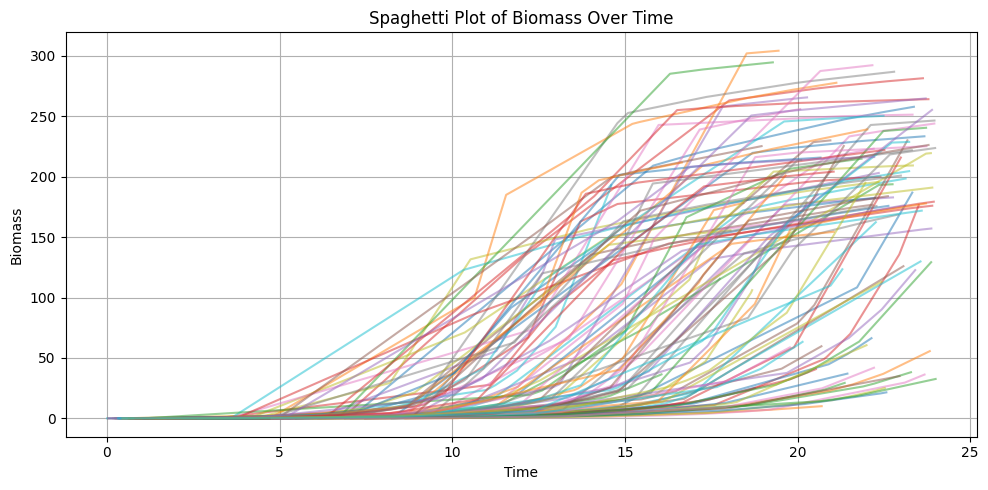

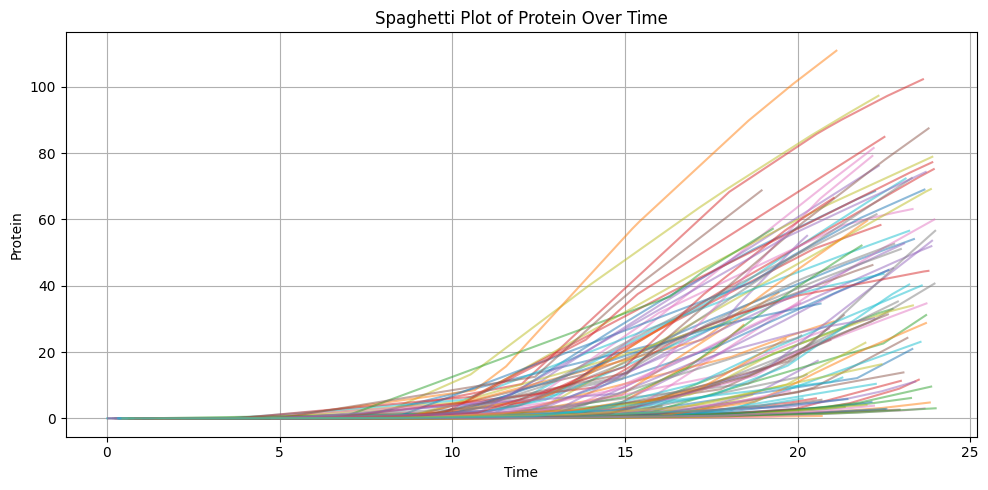

In [8]:

# Spaghetti plot for Biomass
plt.figure(figsize=(10, 5))
for i in range(len(df)):
    plt.plot(time_ticks.iloc[i], biomass.iloc[i], alpha=0.5)
plt.title("Spaghetti Plot of Biomass Over Time")
plt.xlabel("Time")
plt.ylabel("Biomass")
plt.grid(True)
plt.tight_layout()
plt.show()

# Spaghetti plot for Protein
plt.figure(figsize=(10, 5))
for i in range(len(df)):
    plt.plot(time_ticks.iloc[i], protein.iloc[i], alpha=0.5)
plt.title("Spaghetti Plot of Protein Over Time")
plt.xlabel("Time")
plt.ylabel("Protein")
plt.grid(True)
plt.tight_layout()
plt.show()